Problem Statement :

This dataset contains information of users in a social network .This social network has several business business client which  can post ads on it
One of the client has a car companty which has just launched a luxury suv for ridicious price. Build a Bernoullis naiye bayes model usoing this dataset 
and classify whichof the users of the social; network are going to purchase this luxury SUV . 1 implies that there was a purchase and 0 imppolies there wasnt a purchase .

--------------------------------------------------------------------------------------------------------------------------------------------------------
1.Bussiness Problem :

1.1.What is the bussiness objective?                                                                                                                        
1.1.1.This will help you bring those audience to your website who are intrested in cars. And there will be many of those who are planning to buy a car in the near future .                                                                                                                                    1.1.2 Communicating with your target audience over social media is always a great way to build a good market reputation. Try responding to people's automobile related queries on Twitter and Facebook pages quickly to be their first choice when it comes to buying a cor.

1.2. Are there any constraints?

Not having a clear marketing or social media strategy may result in reduced benefits for your business.                                                 Additional resources may be needed to manage your online presence.                                                                                      Social media is immediate and needs daily monitoring                                                                                                    If you don't actively manage your social media presence, you will not see any real benfits . There is a riskk of unwanted or inappropriate behaviour on your site including bullying and harassment . Greater exposuer online has the potential to attract risks . Risks can include negative feedback information , leaks or hacking 

In [5]:
#Work on each feature of the dataset to create a data dictionary as 
#User iD: integer type which is not contibutetrty 
#Gender : object type need to be encoding
#Age : INteger
#Estimated salary : integer 
##purchased : Integer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
 #Let us first import the datsset
car=pd.read_csv("NB_Car_Ad.csv")
car.head()

,User_ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [9]:
#Exploratary data anlaysis
car.columns
car.dtypes
car.describe()
#min age of employe is 18yrs
#max age of employee is 60yrs
#average age is 37.5
#Min salary is 15000
#max salry is 150000
#avrage salary is 69742

,User_ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [11]:
car.isna().sum() #Checking the NAn values

User_ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

(array([51., 39., 58., 50., 82., 40., 22., 19., 17., 22.]),
 array([ 15000.,  28500.,  42000.,  55500.,  69000.,  82500.,  96000.,
        109500., 123000., 136500., 150000.]),
 <BarContainer object of 10 artists>)

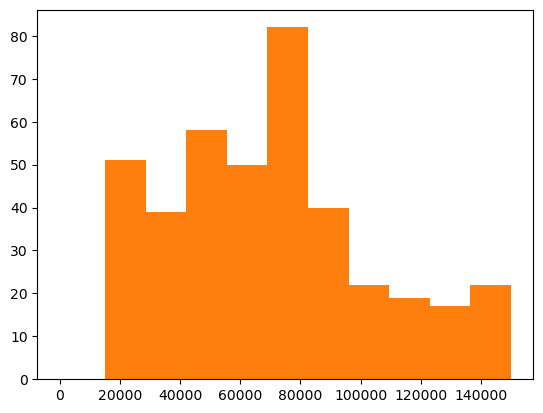

In [13]:
car.isna().sum()
car.drop(['User_ID'],axis=1,inplace=True)
car.dtypes
plt.hist(car.Age)
#Age is normally distributed 
plt.hist(car.EstimatedSalary)

In [15]:
##Data preprocessing 
#Data cleaning Feature Engineering etc
car.dtypes
#the columnbs gender is not object type 
#let us apply label encoder to input features
from sklearn import preprocessing 
label_encoder=preprocessing.LabelEncoder()
#This is the model of label encoder which is applied to all the object tye[p
car["Gender"]=label_encoder.fit_transform(car['Gender'])


In [17]:
#Now let us apply normalization function
def norm_func(i):
    x=(i-i.min())/(i.max()-i.min())
    return x
car_norm=norm_func(car)
car_norm.describe()

,Gender,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000,400.000000
mean,0.490000,0.467976,0.405500,0.357500
std,0.500526,0.249592,0.252570,0.479864
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.279762,0.207407,0.000000
50%,0.000000,0.452381,0.407407,0.000000
75%,1.000000,0.666667,0.540741,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [19]:
#Now let us designate test data and train data 
from sklearn.model_selection import train_test_split
car_train,car_test=train_test_split(car_norm,test_size=0.2)

col_names1=list(car_train.columns)
train_X=car_train[col_names1[0:2]]
train_y=car_train[col_names1[3]]
col_names2=list(car_train.columns)
test_X=car_test[col_names2[0:2]]
test_y=car_test[col_names2[3]]

In [21]:
#Model Building
#Build the model on the scaled data (try multiple options).
#Build a Naive Bayes model. 
#Like MultinomialNB, this classifier is suitable for discrete data. The ce labe
#BernoulliNB is designed for binary/boolean features.
from sklearn.naive_bayes import BernoulliNB as BB
classifier_bb=BB()
classifier_bb.fit(train_X,train_y)
#let us now evaluate on test data 
test_pred_b=classifier_bb.predict(test_X)
#Accuracy of the prediction
accuracy_test_b=np.mean(test_pred_b==test_y)
accuracy_test_b

0.65

In [23]:
#Let us now check confusion m,atrix
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test)
score


NameError: name 'y_test' is not defined